In [1]:
from google.colab import files
uploaded = files.upload()

Saving v2_masked_finetune_db4_t3_norm5_20260305_015938.pt to v2_masked_finetune_db4_t3_norm5_20260305_015938.pt


In [2]:
!pip -q install kagglehub

In [3]:
import kagglehub
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
from torchvision import models
from torchvision import transforms
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import average_precision_score
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import joblib
from collections import Counter

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [5]:
DATA_ROOT = kagglehub.dataset_download("ashery/chexpert")

train_df = pd.read_csv(f"{DATA_ROOT}/train.csv")
valid_df = pd.read_csv(f"{DATA_ROOT}/valid.csv")

def build_full_path(rel_path: str) -> str:
    corrected = rel_path.replace("CheXpert-v1.0-small/", "")
    return os.path.join(DATA_ROOT, corrected)

train_df["FullPath"] = train_df["Path"].apply(build_full_path)
valid_df["FullPath"] = valid_df["Path"].apply(build_full_path)


Using Colab cache for faster access to the 'chexpert' dataset.


In [6]:
test_df = valid_df[valid_df["Frontal/Lateral"] == "Frontal"].reset_index(drop=True)

TARGET_LABELS = [
    "Lung Opacity",
    "Pleural Effusion",
    "Edema",
    "Cardiomegaly",
    "Pneumothorax",
]

FINAL_THRESHOLDS = {
    "Lung Opacity": 0.334,
    "Pleural Effusion": 0.347,
    "Edema": 0.350,
    "Cardiomegaly": 0.332,
    "Pneumothorax": 0.247,
}

THRESHOLDS = [FINAL_THRESHOLDS[l] for l in TARGET_LABELS]
threshold_array = np.array(THRESHOLDS, dtype=float)

CKPT_PATH = "v2_masked_finetune_db4_t3_norm5_20260305_015938.pt"

In [7]:
def make_targets_and_mask(df, target_labels):
    y_raw = df[target_labels].to_numpy()
    mask = np.isin(y_raw, [0, 1]).astype(np.float32)
    y = (y_raw == 1).astype(np.float32)
    return y, mask

y_test, m_test = make_targets_and_mask(test_df, TARGET_LABELS)

for df in [test_df]:
    df["FullPath"] = df["Path"].apply(build_full_path)

In [8]:
class ChexpertDenseNet121(nn.Module):
    def __init__(self, num_labels=5, pretrained=False, freeze_backbone=False):
        super().__init__()
        weights = models.DenseNet121_Weights.DEFAULT if pretrained else None
        self.backbone = models.densenet121(weights=weights)
        self.backbone.classifier = nn.Linear(
            self.backbone.classifier.in_features, num_labels
        )
        if freeze_backbone:
            for p in self.backbone.features.parameters():
                p.requires_grad = False
            for p in self.backbone.classifier.parameters():
                p.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

In [9]:
class CheXpertDatasetMasked(Dataset):
    def __init__(self, df, y, m, transform=None, path_col="FullPath"):
        self.df = df.reset_index(drop=True)
        self.y = y
        self.m = m
        self.transform = transform
        self.path_col = path_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, self.path_col]).convert("RGB")
        if self.transform:
            x = self.transform(img)
        else:
            x = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        return x, torch.from_numpy(self.y[idx]).float(), torch.from_numpy(self.m[idx]).float()

In [10]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_ds = CheXpertDatasetMasked(test_df, y_test, m_test, transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0,
                         pin_memory=torch.cuda.is_available())

model = ChexpertDenseNet121(num_labels=len(TARGET_LABELS))
state = torch.load(CKPT_PATH, map_location=device)
if isinstance(state, dict) and "state_dict" in state:
    state = state["state_dict"]
model.load_state_dict(state, strict=False)
model = model.to(device)
model.eval()

all_probs, all_labels, all_masks = [], [], []
with torch.no_grad():
    for imgs, labels, masks in test_loader:
        logits = model(imgs.to(device))
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.numpy())
        all_masks.append(masks.numpy())

all_probs  = np.concatenate(all_probs,  axis=0)
all_labels = np.concatenate(all_labels, axis=0)
all_masks  = np.concatenate(all_masks,  axis=0)
print("Predictions shape:", all_probs.shape)

Predictions shape: (202, 5)


# classifier performance

In [11]:
auroc_scores = {}
for i, label in enumerate(TARGET_LABELS):
    valid_idx = all_masks[:, i] == 1
    auroc_scores[label] = roc_auc_score(all_labels[valid_idx, i], all_probs[valid_idx, i])

for label, score in auroc_scores.items():
    print(f"{label}: {score:.4f}")
print("Macro AUROC:", round(np.mean(list(auroc_scores.values())), 3))

Lung Opacity: 0.8674
Pleural Effusion: 0.8614
Edema: 0.8815
Cardiomegaly: 0.7872
Pneumothorax: 0.7524
Macro AUROC: 0.83


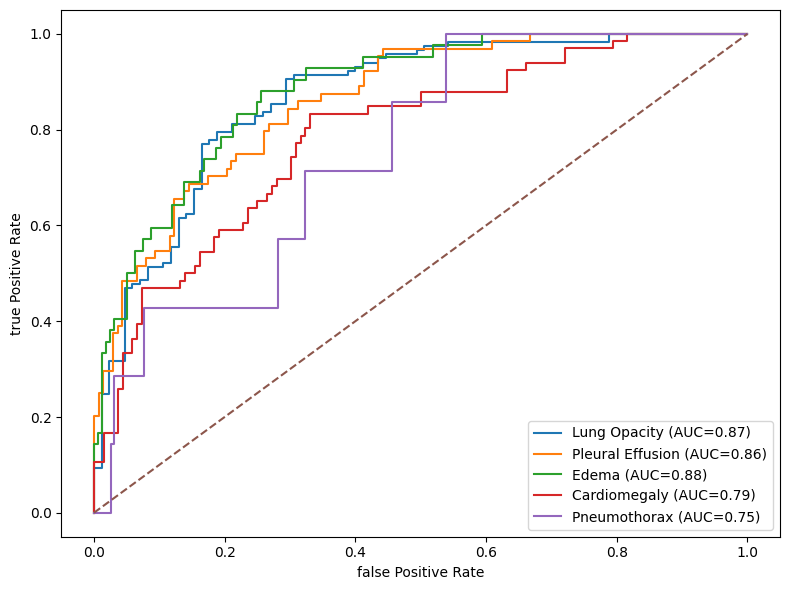

In [12]:
plt.figure(figsize=(8, 6))
for i, label in enumerate(TARGET_LABELS):
    valid_idx = all_masks[:, i] == 1
    fpr, tpr, _ = roc_curve(all_labels[valid_idx, i], all_probs[valid_idx, i])
    auc = auroc_scores[label]
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("false Positive Rate")
plt.ylabel("true Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
auprc_scores = {}
for i, label in enumerate(TARGET_LABELS):
    valid_idx = all_masks[:, i] == 1
    auprc_scores[label] = average_precision_score(all_labels[valid_idx, i], all_probs[valid_idx, i])

for label, score in auprc_scores.items():
    print(f"{label}: {score:.4f}")

Lung Opacity: 0.8863
Pleural Effusion: 0.7623
Edema: 0.6887
Cardiomegaly: 0.6604
Pneumothorax: 0.1215


# per-label confussion matricies

In [14]:
cm_rows = []
for i, label in enumerate(TARGET_LABELS):
    valid_idx = all_masks[:, i] == 1
    y_true = all_labels[valid_idx, i].astype(int)
    y_pred = (all_probs[valid_idx, i] >= THRESHOLDS[i]).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cm_rows.append({
        "Pathology": label,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "Sensitivity": round(tp/(tp+fn), 3) if (tp+fn) > 0 else np.nan,
        "Specificity": round(tn/(tn+fp), 3) if (tn+fp) > 0 else np.nan,
        "PPV": round(tp/(tp+fp), 3) if (tp+fp) > 0 else np.nan,
        "NPV": round(tn/(tn+fn), 3) if (tn+fn) > 0 else np.nan,
    })
display(pd.DataFrame(cm_rows))

,Pathology,TP,FP,TN,FN,Sensitivity,Specificity,PPV,NPV
0,Lung Opacity,107,28,57,10,0.915,0.671,0.793,0.851
1,Pleural Effusion,54,41,97,10,0.844,0.703,0.568,0.907
2,Edema,39,65,95,3,0.929,0.594,0.375,0.969
3,Cardiomegaly,56,61,75,10,0.848,0.551,0.479,0.882
4,Pneumothorax,6,97,98,1,0.857,0.503,0.058,0.990


# threshold generalization test

In [15]:
def compute_sens_thresholds(probs, labels, masks, label_names, target_sensitivity=0.90):
    thresholds_dict = {}
    for i, label in enumerate(label_names):
        valid_idx = masks[:, i] == 1
        y_true = labels[valid_idx, i].astype(int)
        y_prob = probs[valid_idx, i]
        fpr, tpr, thresholds = roc_curve(y_true, y_prob)
        eligible = np.where(tpr >= target_sensitivity)[0]
        chosen = thresholds[eligible].max() if len(eligible) > 0 else thresholds[-1]
        thresholds_dict[label] = float(chosen)
    return thresholds_dict

test_sens90 = compute_sens_thresholds(all_probs, all_labels, all_masks, TARGET_LABELS)

thresh_df = pd.DataFrame({
    "Pathology": TARGET_LABELS,
    "Validation_Threshold": [FINAL_THRESHOLDS[l] for l in TARGET_LABELS],
    "Test_Sens90_Threshold": [test_sens90[l] for l in TARGET_LABELS],
})
thresh_df["Absolute_Difference"] = (thresh_df["Test_Sens90_Threshold"] - thresh_df["Validation_Threshold"]).abs()
thresh_df["Percent_Difference"] = (thresh_df["Absolute_Difference"] / thresh_df["Validation_Threshold"] * 100)
display(thresh_df.round(3))

,Pathology,Validation_Threshold,Test_Sens90_Threshold,Absolute_Difference,Percent_Difference
0,Lung Opacity,0.334,0.354,0.020,6.135
1,Pleural Effusion,0.347,0.195,0.152,43.900
2,Edema,0.350,0.419,0.069,19.780
3,Cardiomegaly,0.332,0.162,0.170,51.343
4,Pneumothorax,0.247,0.227,0.020,8.074


# case-level abnormal detection

In [16]:
preds = (all_probs >= threshold_array.reshape(1, -1)).astype(int)
true_case_abn, pred_case_abn, case_correct, case_error = [], [], [], []

for i in range(len(all_labels)):
    valid_idx = all_masks[i] == 1
    y_true = all_labels[i, valid_idx].astype(int)
    y_pred = preds[i, valid_idx]
    ta = int(np.any(y_true == 1))
    pa = int(np.any(y_pred == 1))
    true_case_abn.append(ta)
    pred_case_abn.append(pa)
    case_correct.append(int(ta == pa))
    case_error.append(int(ta != pa))

test_true_case_abn = np.array(true_case_abn)
test_pred_case_abn = np.array(pred_case_abn)
test_case_correct  = np.array(case_correct)
test_case_error    = np.array(case_error)

print("Case error rate:", test_case_error.mean().round(3))
print("Case accuracy:",   test_case_correct.mean().round(3))

cm = confusion_matrix(test_true_case_abn, test_pred_case_abn, labels=[0, 1])
display(pd.DataFrame(cm,
    index=["True Normal", "True Abnormal"],
    columns=["Pred Normal", "Pred Abnormal"]))

Case error rate: 0.203
Case accuracy: 0.797


,Pred Normal,Pred Abnormal
True Normal,30,33
True Abnormal,8,131


# confidence model eval

In [17]:
from google.colab import files
uploaded = files.upload()

Saving maxprob_reliability_model.pkl to maxprob_reliability_model.pkl


In [18]:
reliability_model = joblib.load("maxprob_reliability_model.pkl")

In [19]:
X_test = np.max(all_probs, axis=1).reshape(-1, 1)
y_test = test_case_error

test_error_probs = reliability_model.predict_proba(X_test)[:, 1]

reliability_auroc = roc_auc_score(y_test, test_error_probs)
brier = brier_score_loss(y_test, test_error_probs)

print(f" AUROC: {reliability_auroc:.3f}")
print(f"Brier score: {brier:.4f}")

max_prob_test = X_test.flatten()
print(f"mean max_prob for correct cases: {max_prob_test[y_test==0].mean():.4f}")
print(f"mean max_prob for error cases:   {max_prob_test[y_test==1].mean():.4f}")

 AUROC: 0.705
Brier score: 0.1605
mean max_prob for correct cases: 0.6540
mean max_prob for error cases:   0.4662


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


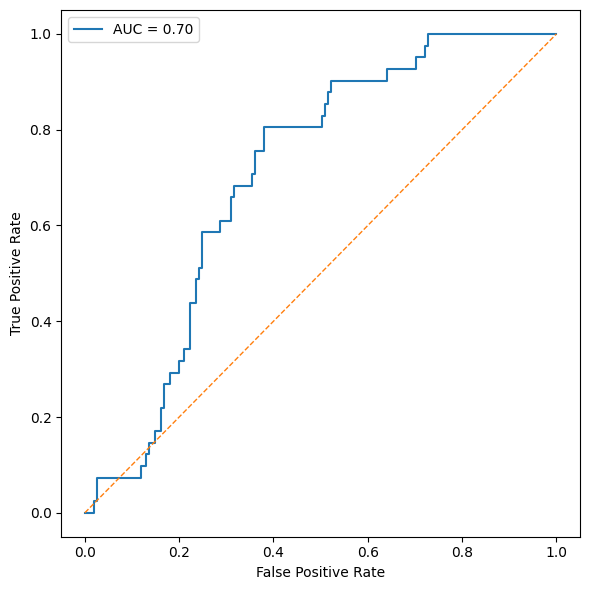

In [20]:
fpr, tpr, _ = roc_curve(y_test, test_error_probs)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {reliability_auroc:.2f}")
plt.plot([0, 1], [0, 1], "--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

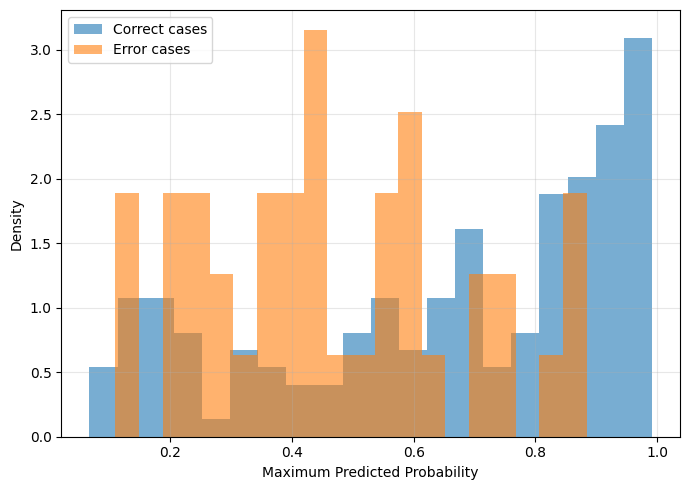

In [21]:
plt.figure(figsize=(7, 5))
plt.hist(max_prob_test[y_test == 0], bins=20, alpha=0.6, density=True, label="Correct cases")
plt.hist(max_prob_test[y_test == 1], bins=20, alpha=0.6, density=True, label="Error cases")
plt.xlabel("Maximum Predicted Probability")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

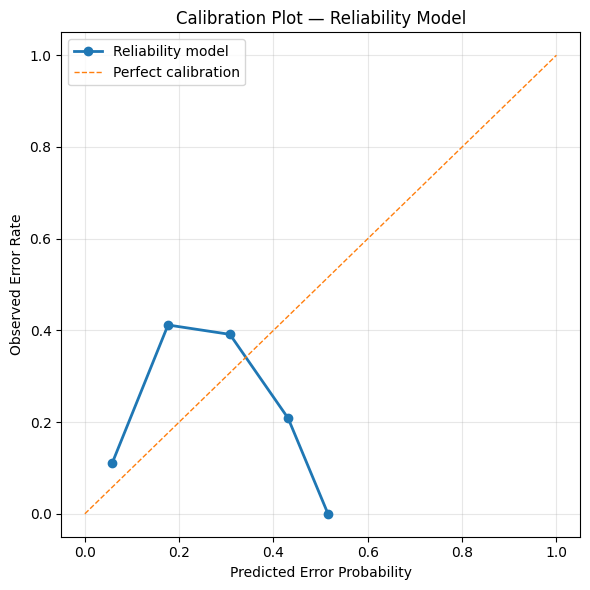

In [22]:
prob_true, prob_pred = calibration_curve(y_test, test_error_probs, n_bins=8, strategy="uniform")
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", linewidth=2, label="Reliability model")
plt.plot([0, 1], [0, 1], "--", linewidth=1, label="Perfect calibration")
plt.xlabel("Predicted Error Probability")
plt.ylabel("Observed Error Rate")
plt.title("Calibration Plot — Reliability Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# selective predicition

In [23]:
def evaluate_selective_prediction(error_probs, y_error, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 41)
    rows = []
    for t in thresholds:
        accept_mask = error_probs <= t
        coverage = accept_mask.mean()
        referral_rate = (~accept_mask).mean()
        if accept_mask.sum() > 0:
            accepted_error_rate = y_error[accept_mask].mean()
            accepted_accuracy = 1 - accepted_error_rate
        else:
            accepted_error_rate = accepted_accuracy = np.nan
        rows.append({
            "error_threshold": t,
            "coverage": coverage,
            "referral_rate": referral_rate,
            "accepted_accuracy": accepted_accuracy,
            "accepted_error_rate": accepted_error_rate,
            "n_accepted": int(accept_mask.sum()),
            "n_referred": int((~accept_mask).sum())
        })
    return pd.DataFrame(rows)

risk_coverage_df = evaluate_selective_prediction(
    error_probs=test_error_probs, y_error=y_test,
    thresholds=np.linspace(0.0, 1.0, 41)
)

FINAL_ERROR_THRESHOLD = 0.10
accept_mask = test_error_probs <= FINAL_ERROR_THRESHOLD
refer_mask = ~accept_mask

summary_thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
summary_df = risk_coverage_df[
    risk_coverage_df["error_threshold"].round(2).isin(summary_thresholds)
].copy()
display(summary_df.round(3))

,error_threshold,coverage,referral_rate,accepted_accuracy,accepted_error_rate,n_accepted,n_referred
2,0.05,0.332,0.668,0.940,0.060,67,135
4,0.10,0.510,0.490,0.922,0.078,103,99
6,0.15,0.639,0.361,0.876,0.124,129,73
8,0.20,0.698,0.302,0.858,0.142,141,61
10,0.25,0.752,0.248,0.822,0.178,152,50
12,0.30,0.812,0.188,0.817,0.183,164,38
16,0.40,0.886,0.114,0.793,0.207,179,23
20,0.50,0.985,0.015,0.794,0.206,199,3


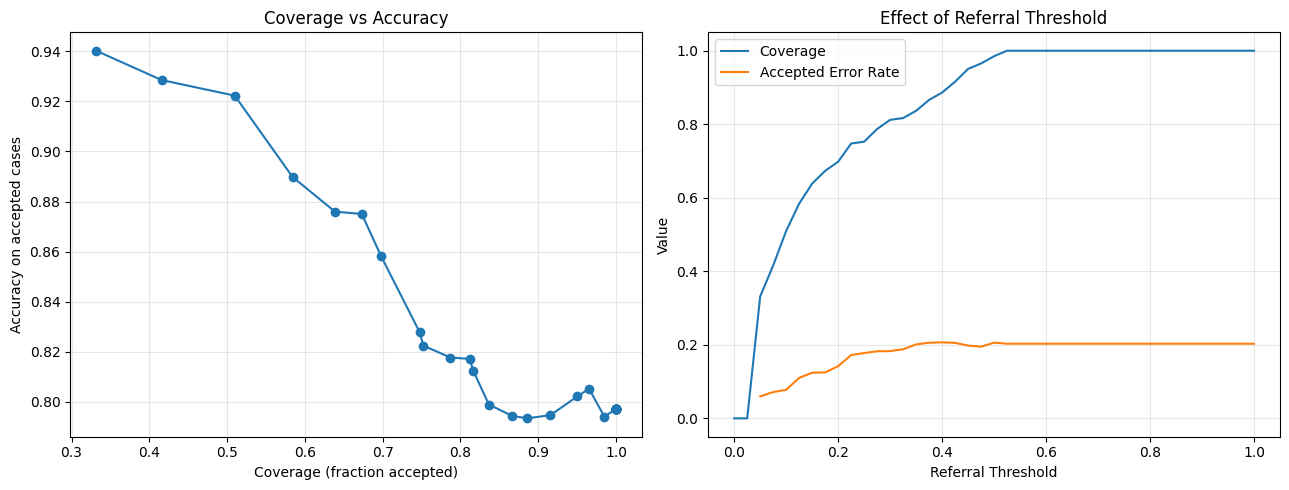

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(risk_coverage_df["coverage"], risk_coverage_df["accepted_accuracy"], marker="o")
axes[0].set_xlabel("Coverage (fraction accepted)")
axes[0].set_ylabel("Accuracy on accepted cases")
axes[0].set_title("Coverage vs Accuracy")
axes[0].grid(True, alpha=0.3)

axes[1].plot(risk_coverage_df["error_threshold"], risk_coverage_df["coverage"], label="Coverage")
axes[1].plot(risk_coverage_df["error_threshold"], risk_coverage_df["accepted_error_rate"], label="Accepted Error Rate")
axes[1].set_xlabel("Referral Threshold")
axes[1].set_ylabel("Value")
axes[1].set_title("Effect of Referral Threshold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
fn_fp_rows = []
for t in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]:
    am = test_error_probs <= t
    if am.sum() == 0:
        continue
    at = test_true_case_abn[am]
    ap = test_pred_case_abn[am]
    fn_fp_rows.append({
        "Error Threshold": t,
        "N Accepted": int(am.sum()),
        "Coverage": round(am.mean(), 3),
        "False Negatives": int(((ap == 0) & (at == 1)).sum()),
        "False Positives": int(((ap == 1) & (at == 0)).sum()),
        "Accepted Accuracy": round((ap == at).mean(), 3),
    })
display(pd.DataFrame(fn_fp_rows))

,Error Threshold,N Accepted,Coverage,False Negatives,False Positives,Accepted Accuracy
0,0.05,67,0.332,0,4,0.940
1,0.10,103,0.510,0,8,0.922
2,0.15,129,0.639,0,16,0.876
3,0.20,141,0.698,0,20,0.858
4,0.30,164,0.812,0,30,0.817
5,0.40,179,0.886,4,33,0.793
6,0.50,199,0.985,8,33,0.794


# reliability signal features

In [26]:
feature_comparison = pd.DataFrame([
    {"Signal": "max_prob (chosen)",  "AUROC": 0.8295},
    {"Signal": "abs_max_margin",      "AUROC": 0.8256},
    {"Signal": "second_max_margin",   "AUROC": 0.7904},
    {"Signal": "max_norm_margin",     "AUROC": 0.7899},
    {"Signal": "closest_abs_margin",  "AUROC": 0.7135},
    {"Signal": "blur",                "AUROC": 0.5564},
    {"Signal": "contrast",            "AUROC": 0.5428},
    {"Signal": "brightness",          "AUROC": 0.5390},
    {"Signal": "entropy_image",       "AUROC": 0.5279},
])
display(feature_comparison)

,Signal,AUROC
0,max_prob (chosen),0.8295
1,abs_max_margin,0.8256
2,second_max_margin,0.7904
3,max_norm_margin,0.7899
4,closest_abs_margin,0.7135
5,blur,0.5564
6,contrast,0.5428
7,brightness,0.5390
8,entropy_image,0.5279


# false positives analysis

In [27]:
case_analysis = []
for i in range(len(all_labels)):
    valid_idx = all_masks[i] == 1
    y_true = all_labels[i, valid_idx].astype(int)
    y_pred_probs = all_probs[i, valid_idx]
    valid_labels = [TARGET_LABELS[j] for j in range(len(TARGET_LABELS)) if all_masks[i, j] == 1]
    true_abnormal = int(np.any(y_true == 1))
    thresh_arr = np.array([FINAL_THRESHOLDS[l] for l in valid_labels])
    y_pred = (y_pred_probs >= thresh_arr).astype(int)
    pred_abnormal = int(np.any(y_pred == 1))
    max_prob = float(np.max(all_probs[i]))
    num_above = int(np.sum(y_pred))
    fired_labels = sorted(
        [(valid_labels[j], float(y_pred_probs[j])) for j in range(len(valid_labels)) if y_pred[j] == 1],
        key=lambda x: x[1], reverse=True
    )
    true_pos_labels = [valid_labels[j] for j in range(len(valid_labels)) if y_true[j] == 1]
    if true_abnormal == 1 and pred_abnormal == 0:
        error_type = "FN"
    elif true_abnormal == 0 and pred_abnormal == 1:
        error_type = "FP"
    else:
        error_type = "correct"
    case_analysis.append({
        "case_idx": i, "true_abnormal": true_abnormal, "pred_abnormal": pred_abnormal,
        "error_type": error_type, "max_prob": max_prob, "num_above_thresh": num_above,
        "fired_labels": [l for l, p in fired_labels], "true_labels": true_pos_labels,
    })

case_df = pd.DataFrame(case_analysis)
print(case_df["error_type"].value_counts())
print(f"\nTotal: {len(case_df)} | FP: {(case_df['error_type']=='FP').sum()} | FN: {(case_df['error_type']=='FN').sum()} | Correct: {(case_df['error_type']=='correct').sum()}")

error_type
correct    161
FP          33
FN           8
Name: count, dtype: int64

Total: 202 | FP: 33 | FN: 8 | Correct: 161


In [28]:
fp_df = case_df[case_df["error_type"] == "FP"].copy()
fn_df = case_df[case_df["error_type"] == "FN"].copy()
correct_df = case_df[case_df["error_type"] == "correct"].copy()

print("\nLabels firing in FP cases:")
fp_fired = Counter([l for labels in fp_df["fired_labels"] for l in labels])
print(pd.Series(fp_fired).sort_values(ascending=False))


Labels firing in FP cases:
Pneumothorax        23
Lung Opacity        15
Cardiomegaly        10
Edema               10
Pleural Effusion     7
dtype: int64


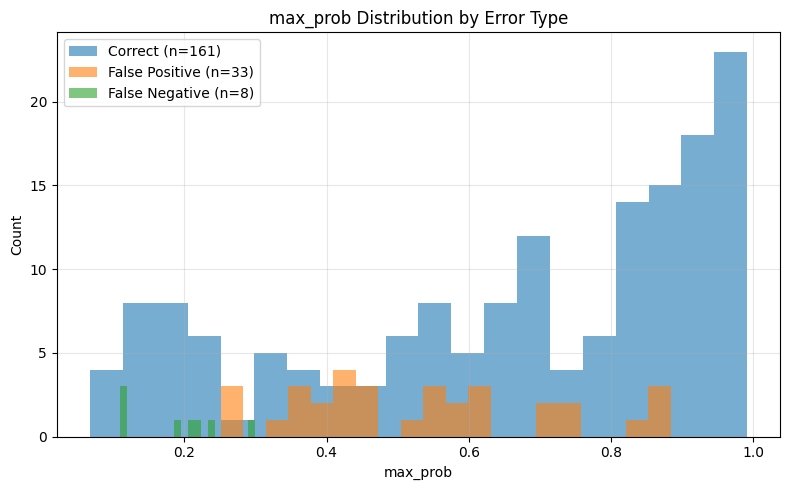

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(correct_df["max_prob"], bins=20, alpha=0.6, label=f"Correct (n={len(correct_df)})")
plt.hist(fp_df["max_prob"], bins=20, alpha=0.6, label=f"False Positive (n={len(fp_df)})")
plt.hist(fn_df["max_prob"], bins=20, alpha=0.6, label=f"False Negative (n={len(fn_df)})")
plt.xlabel("max_prob")
plt.ylabel("Count")
plt.title("max_prob Distribution by Error Type")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# baseline vs system comparision

In [30]:
FINAL_ERROR_THRESHOLD = 0.10
accept_mask = test_error_probs <= FINAL_ERROR_THRESHOLD
refer_mask  = test_error_probs >  FINAL_ERROR_THRESHOLD

base_true = test_true_case_abn
base_pred = test_pred_case_abn
base_tp = int(((base_pred==1)&(base_true==1)).sum())
base_fp = int(((base_pred==1)&(base_true==0)).sum())
base_tn = int(((base_pred==0)&(base_true==0)).sum())
base_fn = int(((base_pred==0)&(base_true==1)).sum())
base_total   = len(base_true)
base_correct = int((base_pred==base_true).sum())
base_accuracy    = base_correct / base_total
base_error_rate  = 1 - base_accuracy

triage_true = test_true_case_abn[accept_mask]
triage_pred = test_pred_case_abn[accept_mask]
triage_tp = int(((triage_pred==1)&(triage_true==1)).sum())
triage_fp = int(((triage_pred==1)&(triage_true==0)).sum())
triage_tn = int(((triage_pred==0)&(triage_true==0)).sum())
triage_fn = int(((triage_pred==0)&(triage_true==1)).sum())
triage_total    = len(triage_true)
triage_correct  = int((triage_pred==triage_true).sum())
triage_accuracy    = triage_correct / triage_total
triage_error_rate  = 1 - triage_accuracy
coverage       = triage_total / base_total
referral_rate  = refer_mask.sum() / base_total

display(pd.DataFrame([
    {
        "System": "Base classifier (no triage)",
        "Coverage": 1.0, "Referral rate": 0.0,
        "Accuracy": round(base_accuracy, 3),
        "Error rate": round(base_error_rate, 3),
        "False negatives": base_fn, "False positives": base_fp,
        "Accepted cases": base_total, "Referred cases": 0,
    },
    {
        "System": f"Triage system (error threshold = {FINAL_ERROR_THRESHOLD})",
        "Coverage": round(coverage, 3),
        "Referral rate": round(referral_rate, 3),
        "Accuracy": round(triage_accuracy, 3),
        "Error rate": round(triage_error_rate, 3),
        "False negatives": triage_fn, "False positives": triage_fp,
        "Accepted cases": triage_total, "Referred cases": int(refer_mask.sum()),
    }
]))

,System,Coverage,Referral rate,Accuracy,Error rate,False negatives,False positives,Accepted cases,Referred cases
0,Base classifier (no triage),1.00,0.00,0.797,0.203,8,33,202,0
1,Triage system (error threshold = 0.1),0.51,0.49,0.922,0.078,0,8,103,99


In [31]:
import numpy as np

n_total = len(test_true_case_abn)
n_accepted = int(accept_mask.sum())
n_trials = 1000

random_accuracies = []
for _ in range(n_trials):
    random_idx = np.random.choice(n_total, size=n_accepted, replace=False)
    y_true = test_true_case_abn[random_idx]
    y_pred = test_pred_case_abn[random_idx]
    acc = (y_true == y_pred).mean()
    random_accuracies.append(acc)

print(f"Random baseline mean accuracy at {n_accepted/n_total:.0%} coverage: {np.mean(random_accuracies):.3f}")
print(f"Random baseline std: {np.std(random_accuracies):.3f}")
print(f"Triage system accuracy: 0.922")

Random baseline mean accuracy at 51% coverage: 0.797
Random baseline std: 0.028
Triage system accuracy: 0.922


In [32]:
random_fps = []
for _ in range(1000):
    random_idx = np.random.choice(n_total, size=n_accepted, replace=False)
    y_true = test_true_case_abn[random_idx]
    y_pred = test_pred_case_abn[random_idx]
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    random_fps.append(fp)

print(f"Random baseline mean FPs at 51% coverage: {np.mean(random_fps):.1f} ± {np.std(random_fps):.1f}")
print(f"Triage system FPs: 8")

Random baseline mean FPs at 51% coverage: 16.9 ± 2.7
Triage system FPs: 8


In [33]:
random_fps = []
random_fns = []
for _ in range(1000):
    random_idx = np.random.choice(n_total, size=n_accepted, replace=False)
    y_true = test_true_case_abn[random_idx]
    y_pred = test_pred_case_abn[random_idx]
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    random_fps.append(fp)
    random_fns.append(fn)

print(f"Random baseline mean FPs: {np.mean(random_fps):.1f} ± {np.std(random_fps):.1f}")
print(f"Random baseline mean FNs: {np.mean(random_fns):.1f} ± {np.std(random_fns):.1f}")
print(f"Triage system FPs: 8, FNs: 0")

Random baseline mean FPs: 16.8 ± 2.7
Random baseline mean FNs: 4.1 ± 1.4
Triage system FPs: 8, FNs: 0


# torchXrayVision comparision

In [ ]:
!pip install -q torchxrayvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 18.2 MB/s eta 0:00:00


In [ ]:
import torchxrayvision as xrv

In [ ]:
XRV_LABEL_MAP = {
    "Lung Opacity":    "Lung Opacity",
    "Pleural Effusion": "Effusion",
    "Edema":           "Edema",
    "Cardiomegaly":    "Cardiomegaly",
    "Pneumothorax":    "Pneumothorax",
}

In [ ]:
xrv_model = xrv.models.get_model("densenet121-res224-chex")
xrv_model = xrv_model.to(device).eval()

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/chex-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/chex-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]


In [ ]:
xrv_label_to_idx = {name: i for i, name in enumerate(xrv_model.pathologies)}
xrv_indices = {
    our_label: xrv_label_to_idx[xrv_name]
    for our_label, xrv_name in XRV_LABEL_MAP.items()
    if xrv_name in xrv_label_to_idx
}

print("Label index mapping:")
for our_label, idx in xrv_indices.items():
    print(f"  {our_label} → '{XRV_LABEL_MAP[our_label]}' (index {idx})")

Label index mapping:
  Lung Opacity → 'Lung Opacity' (index 16)
  Pleural Effusion → 'Effusion' (index 7)
  Edema → 'Edema' (index 4)
  Cardiomegaly → 'Cardiomegaly' (index 10)
  Pneumothorax → 'Pneumothorax' (index 3)


In [ ]:
xrv_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

In [ ]:
class CheXpertXRVDataset(Dataset):
    def __init__(self, df, y, m, transform=None, path_col="FullPath"):
        self.df = df.reset_index(drop=True)
        self.y = y
        self.m = m
        self.transform = transform
        self.path_col = path_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
      img = Image.open(self.df.loc[idx, self.path_col]).convert("L")
      img_np = np.array(img).astype(np.float32)
      img_np = xrv.datasets.normalize(img_np, 255)
      img_tensor = torch.from_numpy(img_np).unsqueeze(0)
      img_tensor = transforms.functional.resize(img_tensor, (224, 224))
      y = torch.tensor(self.y[idx], dtype=torch.float32)
      m = torch.tensor(self.m[idx], dtype=torch.float32)
      return img_tensor, y, m

xrv_test_ds = CheXpertXRVDataset(test_df, y_test, m_test, path_col="FullPath")
xrv_test_loader = DataLoader(
    xrv_test_ds,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [ ]:
xrv_all_probs = []

with torch.no_grad():
    for imgs, _, _ in xrv_test_loader:
        imgs = imgs.to(device)
        out = xrv_model(imgs)
        probs = torch.sigmoid(out)
        xrv_all_probs.append(probs.cpu().numpy())

xrv_all_probs = np.concatenate(xrv_all_probs, axis=0)
print("xrv_all_probs shape:", xrv_all_probs.shape)


xrv_all_probs shape: (202, 18)


In [ ]:
xrv_auroc_scores = {}

for our_label in TARGET_LABELS:
    if our_label not in xrv_indices:
        print(f"Skipping {our_label} - no mapping found")
        continue

    xrv_col_idx = xrv_indices[our_label]
    label_idx = TARGET_LABELS.index(our_label)

    valid_idx = all_masks[:, label_idx] == 1
    y_true = all_labels[valid_idx, label_idx]
    y_prob_xrv = xrv_all_probs[valid_idx, xrv_col_idx]

    xrv_auroc_scores[our_label] = roc_auc_score(y_true, y_prob_xrv)

In [ ]:
comparison_rows = []
for label in TARGET_LABELS:
    comparison_rows.append({
        "Pathology": label,
        "Our Model AUROC": round(auroc_scores[label], 4),
        "TorchXRayVision AUROC": round(xrv_auroc_scores.get(label, float("nan")), 4),
    })

comparison_df = pd.DataFrame(comparison_rows)

our_macro = np.mean([auroc_scores[l] for l in TARGET_LABELS])
xrv_macro = np.nanmean([xrv_auroc_scores.get(l, np.nan) for l in TARGET_LABELS])

comparison_df.loc[len(comparison_df)] = {
    "Pathology": "Macro Average",
    "Our Model AUROC": round(our_macro, 4),
    "TorchXRayVision AUROC": round(xrv_macro, 4),
}

display(comparison_df)

,Pathology,Our Model AUROC,TorchXRayVision AUROC
0,Lung Opacity,0.8674,0.8613
1,Pleural Effusion,0.8614,0.8428
2,Edema,0.8815,0.8271
3,Cardiomegaly,0.7872,0.8079
4,Pneumothorax,0.7524,0.7187
5,Macro Average,0.8300,0.8116
